In [3]:
import os
import csv
import pandas as pd
import re
import subprocess
import numpy as np
import scipy.stats as stats
import scipy.sparse as sp

new_dir = "/home/jingqi/RNALocateV3.0/Data"
os.chdir(new_dir)
os.getcwd()

'/home/jingqi/RNALocateV3.0/Data'

### Overlapping/Validation

In [3]:
file_attract = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates.csv"
file_meme = "FIMO_3UTR/Aginst_MEME_file/Functional_Zipcode_Candidates.csv" 
out_overlap = "ATTRACT_3UTR/FIMO_Processed/FZC_Overlapped.csv"

print("Loading candidate datasets...")
try:
    df_attract = pd.read_csv(file_attract)
    df_meme = pd.read_csv(file_meme)
except FileNotFoundError as e:
    print(f"[FATAL ERROR] Could not find file: {e.filename}")
    exit()

# Extract unique genes from both datasets
genes_attract = set(df_attract['Gene'].dropna())
genes_meme = set(df_meme['Gene'].dropna())

# Calculate the intersection
overlapping_genes = genes_attract.intersection(genes_meme)

# Filter the dataframe to only include the overlapping genes 
# (Using df_attract here, but the gene list is identical)
df_overlap = df_attract[df_attract['Gene'].isin(overlapping_genes)].copy()

# Ensure the output directory exists
os.makedirs(os.path.dirname(out_overlap), exist_ok=True)

# Save the strictly overlapping dataset
df_overlap.to_csv(out_overlap, index=False)

print("\n--- COMPARISON COMPLETE ---")
print(f"Candidates in ATtRACT pipeline: {len(genes_attract)}")
print(f"Candidates in MEME pipeline:    {len(genes_meme)}")
print(f"Strict Overlap (High Confidence): {len(overlapping_genes)}")
print(f"\nFinal filtered dataset saved to: {out_overlap}")

Loading candidate datasets...

--- COMPARISON COMPLETE ---
Candidates in ATtRACT pipeline: 78
Candidates in MEME pipeline:    88
Strict Overlap (High Confidence): 64

Final filtered dataset saved to: ATTRACT_3UTR/FIMO_Processed/FZC_Overlapped.csv


Generating Venn diagram for the overlap...


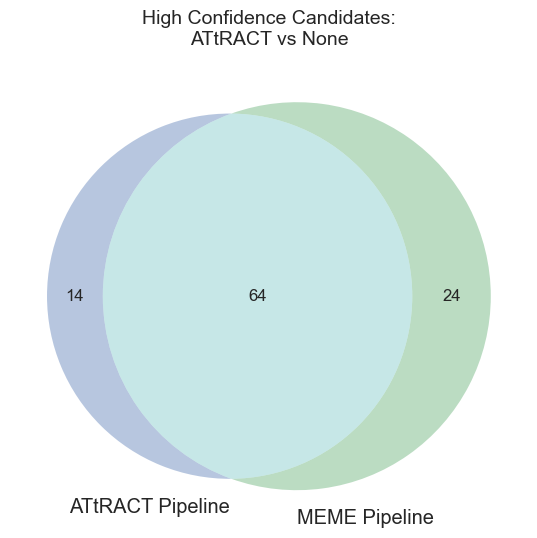

Visualization successfully saved to: ATTRACT_3UTR/FIMO_Processed/FZC_Overlapped_Venn_Diagram.png


In [62]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

print("Generating Venn diagram for the overlap...")

# 1. Strictly define the sets directly from the dataframes again to avoid notebook memory errors
set_attract = set(df_attract['Gene'].dropna())
set_meme = set(df_meme['Gene'].dropna())

# 2. Calculate the exact integer sizes of the 3 Venn regions using strict set methods
only_attract_count = len(set_attract.difference(set_meme))
only_meme_count = len(set_meme.difference(set_attract))
overlap_count = len(set_attract.intersection(set_meme))

# 3. Render the visualization
plt.figure(figsize=(8, 6))

venn_plot = venn2(
    subsets=(only_attract_count, only_meme_count, overlap_count),
    set_labels=('ATtRACT Pipeline', 'MEME Pipeline'),
    set_colors=('#4C72B0', '#55A868')
)

plt.title('High Confidence Candidates:\nATtRACT vs None', fontsize=14, pad=15)

out_venn_png = out_overlap.replace('.csv', '_Venn_Diagram.png')
plt.savefig(out_venn_png, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
plt.show()

print(f"Visualization successfully saved to: {out_venn_png}")

### Adding up

In [4]:
out_union = "ATTRACT_3UTR/FIMO_Processed/FZC_Combined.csv"

print("Loading candidate datasets...")
try:
    df_attract = pd.read_csv(file_attract)
    df_meme = pd.read_csv(file_meme)
except FileNotFoundError as e:
    print(f"[FATAL ERROR] Could not find file: {e.filename}")
    exit()

print("Concatenating datasets...")
df_combined = pd.concat([df_attract, df_meme], ignore_index=True)

# Drop exact duplicate rows, but keep all unique transcripts per gene
df_combined_unique = df_combined.drop_duplicates(subset=['Gene', 'Transcript'], keep='first')

os.makedirs(os.path.dirname(out_union), exist_ok=True)
df_combined_unique.to_csv(out_union, index=False)

genes_attract = df_attract['Gene'].nunique()
genes_meme = df_meme['Gene'].nunique()
total_unique_genes = df_combined_unique['Gene'].nunique()
total_transcripts = len(df_combined_unique)

print("\n--- COMBINATION COMPLETE ---")
print(f"Candidates in ATtRACT pipeline: {genes_attract} genes")
print(f"Candidates in MEME pipeline:    {genes_meme} genes")
print(f"Total Unique Combined Genes:      {total_unique_genes}")
print(f"Total Unique Transcripts Retained: {total_transcripts}")
print(f"\nFinal comprehensive dataset saved to: {out_union}")

Loading candidate datasets...
Concatenating datasets...

--- COMBINATION COMPLETE ---
Candidates in ATtRACT pipeline: 78 genes
Candidates in MEME pipeline:    88 genes
Total Unique Combined Genes:      102
Total Unique Transcripts Retained: 315

Final comprehensive dataset saved to: ATTRACT_3UTR/FIMO_Processed/FZC_Combined.csv


## Cluster genes in cell types

In [9]:
import scanpy as sc

adata = sc.read_h5ad("/home/jingqi/isoforms/adata_thresholded.h5ad")

### Assigning and Clustering

In [12]:
output_dir = "ATTRACT/FIMO_Processed/CellType_Lists"
df_candidates = df_candidates = pd.read_csv(out_union)
os.makedirs(output_dir, exist_ok=True)

CELL_TYPE_COL = "assignments" 
ABSOLUTE_CPM_MIN = 15
DOMINANCE_FRACTION = 0.65

# Clean transcript names to match the AnnData variables
df_candidates['Clean_Transcript'] = df_candidates['Transcript'].str.split('.').str[0]


print("Rebuilding pseudo-bulk CPM matrix...")
if sp.issparse(adata.X):
    raw_counts = adata.X.expm1()
else:
    raw_counts = np.expm1(adata.X)

unique_cell_types = adata.obs[CELL_TYPE_COL].unique()
cell_type_sums = []

for ct in unique_cell_types:
    cells_mask = (adata.obs[CELL_TYPE_COL] == ct).values
    ct_sum = raw_counts[cells_mask].sum(axis=0)
    cell_type_sums.append(np.asarray(ct_sum).flatten())

pseudo_bulk_matrix = np.vstack(cell_type_sums)
library_sizes = pseudo_bulk_matrix.sum(axis=1, keepdims=True)
library_sizes[library_sizes == 0] = 1 
cpm_matrix = (pseudo_bulk_matrix / library_sizes) * 1e6

cpm_df = pd.DataFrame(
    cpm_matrix, 
    index=unique_cell_types, 
    columns=adata.var_names.astype(str).str.split('.').str[0]
)


print(f"Sorting genes by Cell Type (Abs > {ABSOLUTE_CPM_MIN} CPM, Dominance > {DOMINANCE_FRACTION})...")

# Dictionary to hold the final assigned genes for each cell type
cell_type_assignments = {ct: [] for ct in unique_cell_types}

for gene, group in df_candidates.groupby('Gene'):
    transcripts = group['Clean_Transcript'].values
    valid_transcripts = [t for t in transcripts if t in cpm_df.columns]
    
    if not valid_transcripts:
        continue
        
    gene_cpm_matrix = cpm_df[valid_transcripts]
    
    # Evaluate the gene across every cell type
    for cell_type in unique_cell_types:
        ct_expression = gene_cpm_matrix.loc[cell_type]
        total_gene_cpm = ct_expression.sum()
        
        if total_gene_cpm == 0:
            continue
            
        max_transcript = ct_expression.idxmax()
        max_cpm = ct_expression.max()
        fraction = max_cpm / total_gene_cpm
        
        # The Two-Part Gate
        if max_cpm >= ABSOLUTE_CPM_MIN and fraction >= DOMINANCE_FRACTION:
            # Extract the corresponding SCL prediction to include in the output
            transcript_data = group[group['Clean_Transcript'] == max_transcript].iloc[0]
            scl_profile = transcript_data.get('Adjusted_SCL_Profile', 'Unknown')
            
            cell_type_assignments[cell_type].append({
                'Gene': gene,
                'Dominant_Transcript': max_transcript,
                'Absolute_CPM': round(max_cpm, 2),
                'Dominance_Fraction': round(fraction, 3),
                'Localized_To': scl_profile
            })


print("\n--- SORTING COMPLETE ---")
total_assigned = 0

for cell_type, records in cell_type_assignments.items():
    if not records:
        continue
        
    df_ct = pd.DataFrame(records)
    df_ct = df_ct.sort_values(by='Dominance_Fraction', ascending=False)
    
    # Clean the cell type name for safe file saving
    safe_ct_name = str(cell_type).replace('/', '_').replace(' ', '_')
    out_path = os.path.join(output_dir, f"{safe_ct_name}_STRING_List.csv")
    
    df_ct.to_csv(out_path, index=False)
    total_assigned += len(records)
    print(f"{cell_type}: {len(records)} active genes written to {safe_ct_name}_STRING_List.csv")

print(f"\nSuccessfully executed sorting. {total_assigned} total cell-type specific assignments were made.")
print(f"You can find the isolated gene lists for STRING analysis in: {output_dir}/")

Rebuilding pseudo-bulk CPM matrix...
Sorting genes by Cell Type (Abs > 15 CPM, Dominance > 0.65)...

--- SORTING COMPLETE ---
none: 35 active genes written to none_STRING_List.csv
Sensory: 43 active genes written to Sensory_STRING_List.csv
SatGlia: 35 active genes written to SatGlia_STRING_List.csv
BCC: 36 active genes written to BCC_STRING_List.csv
Melanocytes: 31 active genes written to Melanocytes_STRING_List.csv
NCC: 36 active genes written to NCC_STRING_List.csv
Mesenchyme: 25 active genes written to Mesenchyme_STRING_List.csv
ChC: 37 active genes written to ChC_STRING_List.csv
Gut_neuron: 39 active genes written to Gut_neuron_STRING_List.csv
SC: 33 active genes written to SC_STRING_List.csv
tSC: 28 active genes written to tSC_STRING_List.csv
Gut_glia: 36 active genes written to Gut_glia_STRING_List.csv
Symp: 37 active genes written to Symp_STRING_List.csv
nmSC: 31 active genes written to nmSC_STRING_List.csv
mSC: 40 active genes written to mSC_STRING_List.csv
enFib: 35 active gen

In [13]:
import glob

input_dir = "ATTRACT/FIMO_Processed/CellType_Lists"
output_unified_csv = "ATTRACT/FIMO_Processed/CellType_Lists/Unified_CellType_Genes.csv"

file_pattern = os.path.join(input_dir, "*_STRING_List.csv")
csv_files = glob.glob(file_pattern)

cell_type_genes = {}

for file in csv_files:
    filename = os.path.basename(file)
    cell_type = filename.replace("_STRING_List.csv", "")
    
    df = pd.read_csv(file)
    if 'Gene' in df.columns:
        cell_type_genes[cell_type] = df['Gene'].tolist()

if not cell_type_genes:
    print(f"Error: No valid files found in {input_dir}.")
else:
    unified_df = pd.concat([pd.Series(genes, name=ct) for ct, genes in cell_type_genes.items()], axis=1)
    unified_df.to_csv(output_unified_csv, index=False)
    print(f"Unified file successfully generated with {len(unified_df.columns)} cell types.")
    print(f"Saved to: {output_unified_csv}")

Unified file successfully generated with 16 cell types.
Saved to: ATTRACT/FIMO_Processed/CellType_Lists/Unified_CellType_Genes.csv


## Cluster genes based on RBP

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict

In [30]:
input_csv = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP_Driven_Clusters_new.csv"

df = pd.read_csv(input_csv)

# Global tracking structures
rbp_gene_assignments = defaultdict(set)
rbp_scl_scoreboard = defaultdict(lambda: defaultdict(int))

def get_motifs(motif_str):
    if pd.isna(motif_str) or motif_str == 'None': return set()
    return set(x.strip() for x in str(motif_str).split(',') if x.strip())

def get_scls(scl_str):
    if pd.isna(scl_str) or scl_str == 'Unclassified': return set()
    return set(x.strip() for x in str(scl_str).split(',') if x.strip())

print("Executing RBP Pattern Clustering and Global SCL Voting...")

for gene, group in df.groupby('Gene'):
    transcripts = group.reset_index(drop=True)
    n_transcripts = len(transcripts)
    
    if n_transcripts < 2:
        continue
        
    # Build Motif Presence/Absence Matrix for the Gene
    all_motifs = list(set.union(*[get_motifs(m) for m in transcripts['Motif_Profile']]))
    if not all_motifs:
        continue
        
    matrix = np.zeros((n_transcripts, len(all_motifs)))
    for i, row in transcripts.iterrows():
        t_motifs = get_motifs(row['Motif_Profile'])
        for j, motif in enumerate(all_motifs):
            if motif in t_motifs:
                matrix[i, j] = 1
                
    # Pattern Division (K=2)
    if n_transcripts == 2:
        labels = np.array([0, 1])
    else:
        # Prevent failure if all transcripts are structurally identical
        if np.all(matrix == matrix[0]):
            continue
        clusterer = AgglomerativeClustering(n_clusters=2, metric='cosine', linkage='average')
        labels = clusterer.fit_predict(matrix)
        
        # If clustering fails to separate them, skip
        if len(set(labels)) < 2:
            continue
            
    # Select Representative Transcript for Each Pattern
    reps = {}
    for cluster_id in [0, 1]:
        indices = np.where(labels == cluster_id)[0]
        if len(indices) == 1:
            reps[cluster_id] = indices[0]
        else:
            sub_matrix = matrix[indices]
            sim_matrix = cosine_similarity(sub_matrix)
            # Find the transcript with the highest average similarity to others in its pattern
            avg_sim = sim_matrix.mean(axis=1)
            best_idx_local = np.argmax(avg_sim)
            reps[cluster_id] = indices[best_idx_local]
            
    rep_A_idx, rep_B_idx = reps[0], reps[1]
    
    motifs_A = get_motifs(transcripts.iloc[rep_A_idx]['Motif_Profile'])
    motifs_B = get_motifs(transcripts.iloc[rep_B_idx]['Motif_Profile'])
    
    scls_A = get_scls(transcripts.iloc[rep_A_idx]['Adjusted_SCL_Profile'])
    scls_B = get_scls(transcripts.iloc[rep_B_idx]['Adjusted_SCL_Profile'])
    
    # Subtraction across the Representatives
    unique_motifs_A = motifs_A - motifs_B
    unique_motifs_B = motifs_B - motifs_A
    unique_scls_A = scls_A - scls_B
    unique_scls_B = scls_B - scls_A
    
    # Global Scoreboard Assignment
    # If Pattern A has unique SCLs, assign points to Pattern A's unique RBPs
    if unique_scls_A:
        for rbp in unique_motifs_A:
            rbp_gene_assignments[rbp].add(gene)
            for scl in unique_scls_A:
                rbp_scl_scoreboard[rbp][scl] += 1
                
    # Repeat for Pattern B
    if unique_scls_B:
        for rbp in unique_motifs_B:
            rbp_gene_assignments[rbp].add(gene)
            for scl in unique_scls_B:
                rbp_scl_scoreboard[rbp][scl] += 1

# Resolve the Scoreboard and Format Output
records = []
for rbp in rbp_scl_scoreboard.keys():
    scl_counts = rbp_scl_scoreboard[rbp]
    total_votes = sum(scl_counts.values())
    
    if total_votes == 0:
        continue
        
    # Sort all SCLs for this RBP by their vote count (highest to lowest)
    sorted_scls = sorted(scl_counts.items(), key=lambda item: item[1], reverse=True)
    
    # Strictly select the Top 3 (or fewer, if it only has 1 or 2)
    top_scls = sorted_scls[:3]
    
    # Format the output string (e.g., "Nucleus (42) | Cytoplasm (12) | Membrane (3)")
    formatted_scls = [f"{scl} ({votes})" for scl, votes in top_scls]
    
    records.append({
        'RBP_Motif': rbp,
        'Target_Gene_Count': len(rbp_gene_assignments[rbp]),
        'Regulated_Genes': ", ".join(sorted(list(rbp_gene_assignments[rbp]))),
        'Driven_Destinations': " | ".join(formatted_scls),
        'Total_SCL_Votes': total_votes
    })

# Export
df_out = pd.DataFrame(records)
df_out = df_out.sort_values(by='Target_Gene_Count', ascending=False)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_out.to_csv(output_csv, index=False)

print(f"Network isolated: {len(df_out)} unique RBPs driving differential localization.")
print(f"Results saved to: {output_csv}")

Executing RBP Pattern Clustering and Global SCL Voting...
Network isolated: 18 unique RBPs driving differential localization.
Results saved to: ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP_Driven_Clusters_new.csv


## Cluster on RBP + Cell type

In [18]:
## Preparation. Configuration

import matplotlib.pyplot as plt
import seaborn as sns

rbp_network_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP_Driven_Clusters_new.csv" 
combined_candidates_csv = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"

      

# Helper functions
def get_motifs(motif_str):
    if pd.isna(motif_str) or motif_str == 'None': return set()
    return set(x.strip() for x in str(motif_str).split(',') if x.strip())

def get_scls(scl_str):
    if pd.isna(scl_str) or scl_str == 'Unclassified': return set()
    return set(x.strip() for x in str(scl_str).split(',') if x.strip())

# Load Data and Rebuild CPM Matrix
print("Loading data and building pseudo-bulk matrices...")
df = pd.read_csv(input_csv)
df['Clean_Transcript'] = df['Transcript'].str.split('.').str[0]

gene_to_all_transcripts = df.groupby('Gene')['Clean_Transcript'].unique().to_dict()

if sp.issparse(adata.X):
    raw_counts = adata.X.expm1()
else:
    raw_counts = np.expm1(adata.X)

unique_cell_types = adata.obs['assignments'].unique()
cell_type_sums = [np.asarray(raw_counts[(adata.obs['assignments'] == ct).values].sum(axis=0)).flatten() for ct in unique_cell_types]
pseudo_bulk_matrix = np.vstack(cell_type_sums)
library_sizes = np.where(pseudo_bulk_matrix.sum(axis=1, keepdims=True) == 0, 1, pseudo_bulk_matrix.sum(axis=1, keepdims=True))
cpm_matrix = (pseudo_bulk_matrix / library_sizes) * 1e6

cpm_df = pd.DataFrame(cpm_matrix, index=unique_cell_types, columns=adata.var_names.astype(str).str.split('.').str[0])


# Set the global theme for all following plots
sns.set_theme(style="whitegrid")

Loading data and building pseudo-bulk matrices...


### Plot A

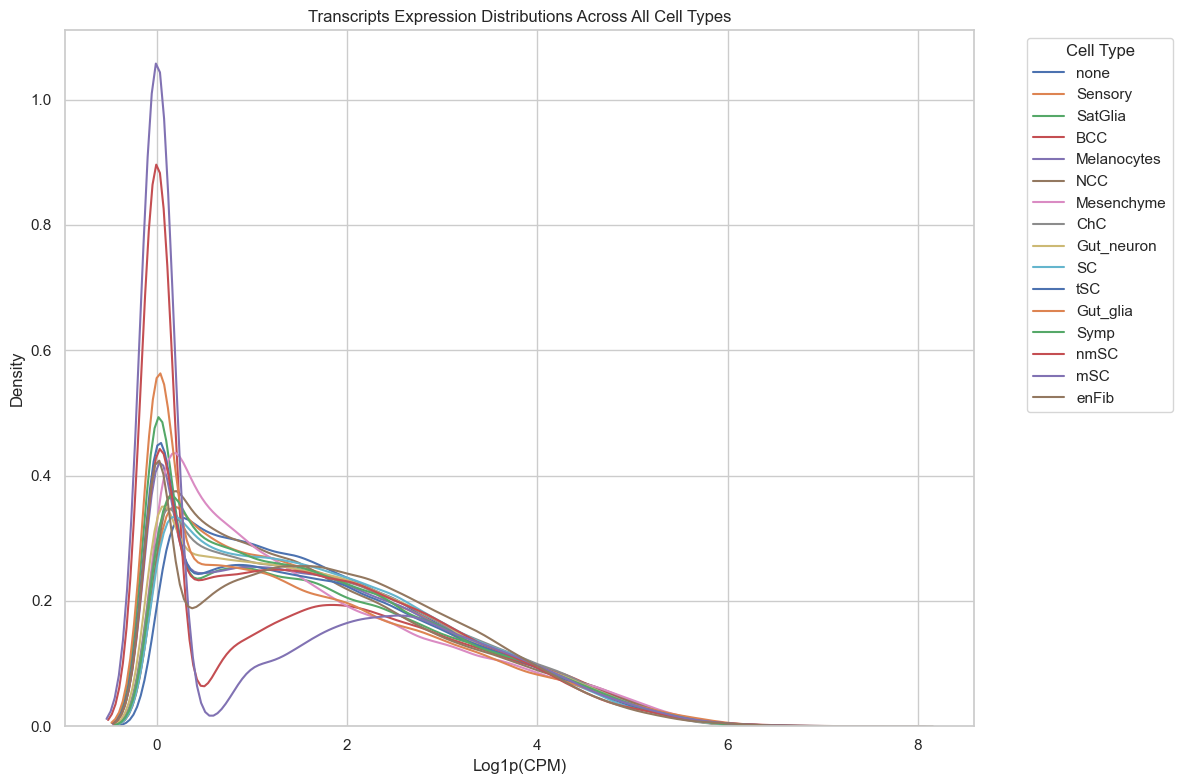

In [21]:
## before deciding the thresholds, it would only be better to visualize

# Plot A: Absolute Expression Distribution for a specific cell type
plt.figure(figsize=(12, 8))

# Iterate over every unique cell type
for cell_type in unique_cell_types:
    # Extract the row vector for the current cell type
    cell_type_expression = cpm_df.loc[cell_type]
    
    # Plot only the KDE curve, bypassing the dense histogram bars
    sns.kdeplot(np.log1p(cell_type_expression), label=cell_type, linewidth=1.5)

plt.title("Transcripts Expression Distributions Across All Cell Types")
plt.xlabel("Log1p(CPM)")
plt.ylabel("Density")

# Position the legend outside the plot to prevent it from obscuring the curves
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
## According to this profile, log(1+x) = 0.25, x = 0.778; log(1+x) = 2, x = 99

### Plot B

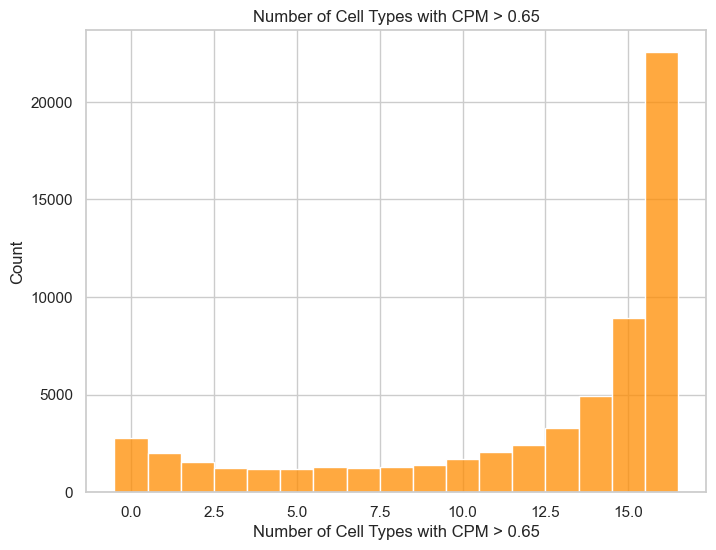

In [22]:
# Plot B: Transcript Breadth (Housekeeping potential)
plt.figure(figsize=(8, 6))

# Calculates how many cell types express a transcript above a baseline CPM of 5
cells_expressing = (cpm_df > 0.65).sum(axis=0)

sns.histplot(cells_expressing, discrete=True, color="darkorange")
plt.title("Number of Cell Types with CPM > 0.65")
plt.xlabel("Number of Cell Types with CPM > 0.65")
plt.ylabel("Count")
plt.show()

In [25]:
## Perhaps 14 or 15 would be fair

### Plot C

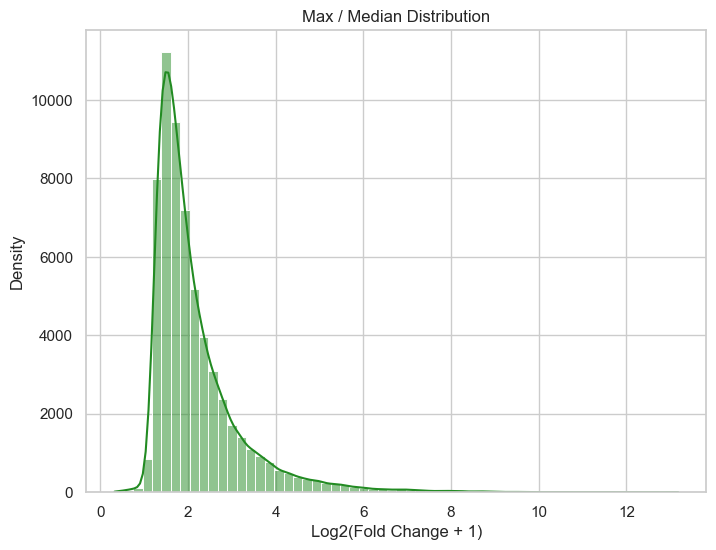

In [23]:
# Plot C: Fold Change Specificity
plt.figure(figsize=(8, 6))

# Calculates the ratio of the max cell type expression to the median of all other cell types
max_cpm_per_transcript = cpm_df.max(axis=0)
median_cpm_per_transcript = cpm_df.median(axis=0)

# A small pseudocount (0.1) prevents division by zero for silent transcripts
fold_change = max_cpm_per_transcript / (median_cpm_per_transcript + 0.1)

sns.histplot(np.log2(fold_change + 1), bins=60, kde=True, color="forestgreen")
plt.title("Max / Median Distribution")
plt.xlabel("Log2(Fold Change + 1)")
plt.ylabel("Density")
plt.show()

In [ ]:
## (1.75, 2) which means the fold is (2.4, 3) would be good.

In [33]:
## Three thresholds

## First we exclude housekeeping transcripts from the patterns, 
## those that have absolut expression higher than 5 in 14 cell types or more

## For each cell type, examine the genes one by one. 

## 1.If the gene has one pattern where there are transcripts
## having absolut expression than 5 in that cell type, but the other pattern has none;
## 2. Within that pattern, pick the one with highest expression in that cell,
## if the expression is 2.4 times higher than in other cell types;

## Then we assign that gene to that cell type.

In [24]:
ABSOLUTE_CPM_MIN = 0.65
HOUSEKEEPING_MIN_CELLS = 14
FOLD_CHANGE_MIN = 1.8

print("Applying Assignment Gates (Binary Pattern Expression, Fold-Change)...")
rbp_cell_genes = defaultdict(lambda: defaultdict(set))

# Pre-calculate transcript breadth to identify and exclude housekeeping transcripts globally
transcript_breadth = (cpm_df > ABSOLUTE_CPM_MIN).sum(axis=0)

for rbp, gene_dict in rbp_gene_driven_transcripts.items():
    for gene, specific_transcripts in gene_dict.items():
        
        all_gene_transcripts = [t for t in gene_to_all_transcripts.get(gene, []) if t in cpm_df.columns]
        driven_transcripts = [t for t in specific_transcripts if t in cpm_df.columns]
        other_transcripts = [t for t in all_gene_transcripts if t not in driven_transcripts]
        
        # Exclude housekeeping transcripts from both pattern subsets
        valid_driven = [t for t in driven_transcripts if transcript_breadth[t] < HOUSEKEEPING_MIN_CELLS]
        valid_other = [t for t in other_transcripts if transcript_breadth[t] < HOUSEKEEPING_MIN_CELLS]
        
        if not valid_driven: 
            continue
            
        driven_cpm_matrix = cpm_df[valid_driven]
        
        if valid_other:
            other_cpm_matrix = cpm_df[valid_other]
        else:
            other_cpm_matrix = pd.DataFrame(0, index=cpm_df.index, columns=['dummy'])
            
        driven_max_series = driven_cpm_matrix.max(axis=1)

        for cell_type in unique_cell_types:
            # Condition 1a: The driven pattern must have at least one transcript > 5 CPM
            if driven_max_series[cell_type] <= ABSOLUTE_CPM_MIN:
                continue
                
            # Condition 1b: The other pattern must be completely silent (no transcripts > 5 CPM)
            if valid_other and (other_cpm_matrix.loc[cell_type] > ABSOLUTE_CPM_MIN).any():
                continue
                
            # Condition 2: Evaluate the highest transcript within the active driven pattern
            highest_t = driven_cpm_matrix.loc[cell_type].idxmax()
            t_expression = cpm_df[highest_t]
            
            # Calculate the median expression of this specific transcript across all other cell types
            other_cells_median = t_expression.drop(cell_type).median()
            
            if t_expression[cell_type] >= (other_cells_median * FOLD_CHANGE_MIN):
                rbp_cell_genes[rbp][cell_type].add(gene)

# Format Output
records = []
for rbp, cell_types_dict in rbp_cell_genes.items():
    for cell_type, active_genes in cell_types_dict.items():
        records.append({
            'RBP': rbp,
            'Cell_Type': cell_type,
            'Active_Genes': ", ".join(sorted(list(active_genes))),
            'Target_Gene_Count': len(active_genes),
            'Driven_Destinations': rbp_destinations.get(rbp, "Unknown")
        })

df_out = pd.DataFrame(records)
if not df_out.empty:
    df_out = df_out.sort_values(by=['RBP', 'Target_Gene_Count'], ascending=[True, False]).reset_index(drop=True)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_out.to_csv(output_csv, index=False)

print(f"\n--- PIPELINE COMPLETE ---")
print(f"Filtered networks saved to: {output_csv}")

Applying Assignment Gates (Binary Pattern Expression, Fold-Change)...


NameError: name 'rbp_gene_driven_transcripts' is not defined

In [57]:
## little trimming of AGO2_C1

input_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"

print(f"Loading network data from {input_csv}...")
df = pd.read_csv(input_csv)

initial_rows = len(df)
df_cleaned = df[df['RBP'] != 'AGO2_C1'].copy()
final_rows = len(df_cleaned)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_cleaned.to_csv(output_csv, index=False)

print(f"Successfully dropped AGO2_C1.")
print(f"Network trimmed from {initial_rows} to {final_rows} specific interactions.")
print(f"Cleaned dataset saved to: {output_csv}")

Loading network data from ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv...
Successfully dropped AGO2_C1.
Network trimmed from 241 to 226 specific interactions.
Cleaned dataset saved to: ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv


## First strip housekeeping transcripts and then cluster

In [28]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import os
from collections import defaultdict
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

# --- CONFIGURATION ---
input_csv = "ATTRACT_3UTR/FIMO_Processed/Functional_Zipcode_Candidates_new.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/Context_Driven_Networks.csv"

cell_type_col = "assignments"
ABSOLUTE_CPM_MIN = 6
HOUSEKEEPING_MIN_CELLS = 14
FOLD_CHANGE_MIN = 3

# Helper functions
def get_motifs(motif_str):
    if pd.isna(motif_str) or motif_str == 'None': return set()
    return set(x.strip() for x in str(motif_str).split(',') if x.strip())

def get_scls(scl_str):
    if pd.isna(scl_str) or scl_str == 'Unclassified': return set()
    return set(x.strip() for x in str(scl_str).split(',') if x.strip())

# 1. load data and rebuild CPM matrix
print("Loading data and building pseudo-bulk matrices...")
df = pd.read_csv(input_csv)
df['Clean_Transcript'] = df['Transcript'].str.split('.').str[0]

if sp.issparse(adata.X):
    raw_counts = adata.X.expm1()
else:
    raw_counts = np.expm1(adata.X)

unique_cell_types = adata.obs[cell_type_col].unique()
cell_type_sums = [np.asarray(raw_counts[(adata.obs[cell_type_col] == ct).values].sum(axis=0)).flatten() for ct in unique_cell_types]
pseudo_bulk_matrix = np.vstack(cell_type_sums)
library_sizes = np.where(pseudo_bulk_matrix.sum(axis=1, keepdims=True) == 0, 1, pseudo_bulk_matrix.sum(axis=1, keepdims=True))
cpm_matrix = (pseudo_bulk_matrix / library_sizes) * 1e6

cpm_df = pd.DataFrame(cpm_matrix, index=unique_cell_types, columns=adata.var_names.astype(str).str.split('.').str[0])

# 2. housesekeeping filter
print("Identifying and stripping housekeeping transcripts...")
transcript_breadth = (cpm_df > ABSOLUTE_CPM_MIN).sum(axis=0)
housekeeping_transcripts = set(transcript_breadth[transcript_breadth >= HOUSEKEEPING_MIN_CELLS].index)

df_dynamic = df[~df['Clean_Transcript'].isin(housekeeping_transcripts)].copy()
print(f"Removed {len(housekeeping_transcripts)} housekeeping transcripts. Remaining dynamic transcripts: {len(df_dynamic)}")

# Global tracking structures
# rbp -> cell_type -> set(genes)
rbp_cell_genes = defaultdict(lambda: defaultdict(set))
# rbp -> cell_type -> scl -> vote_count
rbp_cell_scl_votes = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

# 3. unified clustering and directional assignment loop
print("Executing unified structural clustering and directional cell-type voting...")

for gene, group in df_dynamic.groupby('Gene'):
    transcripts = group.reset_index(drop=True)
    n_transcripts = len(transcripts)
    
    if n_transcripts < 2:
        continue
        
    # Build Motif Presence/Absence Matrix
    all_motifs = list(set.union(*[get_motifs(m) for m in transcripts['Motif_Profile']]))
    if not all_motifs: continue
        
    matrix = np.zeros((n_transcripts, len(all_motifs)))
    for i, row in transcripts.iterrows():
        t_motifs = get_motifs(row['Motif_Profile'])
        for j, motif in enumerate(all_motifs):
            if motif in t_motifs: matrix[i, j] = 1
            
    # Pattern Division (K=2)
    if n_transcripts == 2:
        labels = np.array([0, 1])
    else:
        if np.all(matrix == matrix[0]): continue
        clusterer = AgglomerativeClustering(n_clusters=2, metric='cosine', linkage='average')
        labels = clusterer.fit_predict(matrix)
        if len(set(labels)) < 2: continue
            
    # Select Representatives
    reps = {}
    for cluster_id in [0, 1]:
        indices = np.where(labels == cluster_id)[0]
        if len(indices) == 1:
            reps[cluster_id] = indices[0]
        else:
            sub_matrix = matrix[indices]
            sim_matrix = cosine_similarity(sub_matrix)
            avg_sim = sim_matrix.mean(axis=1)
            reps[cluster_id] = indices[np.argmax(avg_sim)]
            
    rep_A_idx, rep_B_idx = reps[0], reps[1]
    row_A, row_B = transcripts.iloc[rep_A_idx], transcripts.iloc[rep_B_idx]
    
    # Calculate Directional Unique Features
    uniq_motifs_A = get_motifs(row_A['Motif_Profile']) - get_motifs(row_B['Motif_Profile'])
    uniq_motifs_B = get_motifs(row_B['Motif_Profile']) - get_motifs(row_A['Motif_Profile'])
    uniq_scls_A = get_scls(row_A['Adjusted_SCL_Profile']) - get_scls(row_B['Adjusted_SCL_Profile'])
    uniq_scls_B = get_scls(row_B['Adjusted_SCL_Profile']) - get_scls(row_A['Adjusted_SCL_Profile'])
    
    # Isolate transcript lists for expression checking
    t_list_A = [t for t in transcripts.iloc[np.where(labels == 0)[0]]['Clean_Transcript'] if t in cpm_df.columns]
    t_list_B = [t for t in transcripts.iloc[np.where(labels == 1)[0]]['Clean_Transcript'] if t in cpm_df.columns]
    
    if not t_list_A and not t_list_B: continue
        
    cpm_A = cpm_df[t_list_A] if t_list_A else None
    cpm_B = cpm_df[t_list_B] if t_list_B else None
    
    max_cpm_A = cpm_A.max(axis=1) if cpm_A is not None else pd.Series(0, index=cpm_df.index)
    max_cpm_B = cpm_B.max(axis=1) if cpm_B is not None else pd.Series(0, index=cpm_df.index)

    # Scan across cell types for active toggle switches
    for ct in unique_cell_types:
        
        # Test 1: Pattern A is Active, Pattern B is Silent
        if max_cpm_A[ct] > ABSOLUTE_CPM_MIN and max_cpm_B[ct] <= ABSOLUTE_CPM_MIN:
            if uniq_motifs_A and uniq_scls_A:
                highest_t_A = cpm_A.loc[ct].idxmax()
                t_expr = cpm_df[highest_t_A]
                median_other = t_expr.drop(ct).median()
                
                # Verify specificity of the active transcript
                if t_expr[ct] >= (median_other * FOLD_CHANGE_MIN):
                    for rbp in uniq_motifs_A:
                        rbp_cell_genes[rbp][ct].add(gene)
                        for scl in uniq_scls_A:
                            rbp_cell_scl_votes[rbp][ct][scl] += 1
                            
        # Test 2: Pattern B is Active, Pattern A is Silent
        if max_cpm_B[ct] > ABSOLUTE_CPM_MIN and max_cpm_A[ct] <= ABSOLUTE_CPM_MIN:
            if uniq_motifs_B and uniq_scls_B:
                highest_t_B = cpm_B.loc[ct].idxmax()
                t_expr = cpm_df[highest_t_B]
                median_other = t_expr.drop(ct).median()
                
                # Verify specificity of the active transcript
                if t_expr[ct] >= (median_other * FOLD_CHANGE_MIN):
                    for rbp in uniq_motifs_B:
                        rbp_cell_genes[rbp][ct].add(gene)
                        for scl in uniq_scls_B:
                            rbp_cell_scl_votes[rbp][ct][scl] += 1

# 4. resolve scorreborads and format output
print("Formatting directional network topology...")
records = []

for rbp, ct_dict in rbp_cell_genes.items():
    for ct, active_genes in ct_dict.items():
        if not active_genes: continue
            
        scl_counts = rbp_cell_scl_votes[rbp][ct]
        if sum(scl_counts.values()) == 0: continue
            
        # Get top SCLs driven by this specific RBP in this specific Cell Type
        sorted_scls = sorted(scl_counts.items(), key=lambda item: item[1], reverse=True)[:3]
        formatted_scls = " | ".join([f"{scl} ({votes})" for scl, votes in sorted_scls])
        
        records.append({
            'RBP': rbp,
            'Cell_Type': ct,
            'Target_Gene_Count': len(active_genes),
            'Active_Genes': ", ".join(sorted(list(active_genes))),
            'Driven_Destinations': formatted_scls
        })

df_out = pd.DataFrame(records)
if not df_out.empty:
    df_out = df_out.sort_values(by=['Target_Gene_Count', 'RBP', 'Cell_Type'], ascending=[False, True, True]).reset_index(drop=True)
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    df_out.to_csv(output_csv, index=False)

print(f"Network isolated: {len(df_out['RBP'].unique()) if not df_out.empty else 0} RBPs across {len(df_out['Cell_Type'].unique()) if not df_out.empty else 0} Cell Types.")
print(f"Results saved to: {output_csv}")

Loading data and building pseudo-bulk matrices...
Identifying and stripping housekeeping transcripts...
Removed 2724 housekeeping transcripts. Remaining dynamic transcripts: 663
Executing unified structural clustering and directional cell-type voting...
Formatting directional network topology...
Network isolated: 18 RBPs across 16 Cell Types.
Results saved to: ATTRACT_3UTR/FIMO_Processed/RBP_Lists/Context_Driven_Networks.csv


In [29]:
## little trimming of AGO2_C1

input_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"

print(f"Loading network data from {input_csv}...")
df = pd.read_csv(input_csv)

initial_rows = len(df)
df_cleaned = df[df['RBP'] != 'AGO2_C1'].copy()
final_rows = len(df_cleaned)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_cleaned.to_csv(output_csv, index=False)

print(f"Successfully dropped AGO2_C1.")
print(f"Network trimmed from {initial_rows} to {final_rows} specific interactions.")
print(f"Cleaned dataset saved to: {output_csv}")

Loading network data from ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv...
Successfully dropped AGO2_C1.
Network trimmed from 226 to 226 specific interactions.
Cleaned dataset saved to: ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv


In [36]:
import pandas as pd
import re
from collections import defaultdict

# --- CONFIGURATION ---
input_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP-CellType_lists_2.csv"
output_csv = "ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP_Driven_Clusters_new.csv"

# Load the file you already generated
df = pd.read_csv(input_csv)

# Tracking dictionaries
rbp_genes = defaultdict(set)
rbp_scl_votes = defaultdict(lambda: defaultdict(int))

print("Parsing existing network results...")

for _, row in df.iterrows():
    rbp = row['RBP']
    
    # 1. Deduplicate genes globally per RBP
    if pd.notna(row['Active_Genes']):
        genes = [g.strip() for g in str(row['Active_Genes']).split(',') if g.strip()]
        for g in genes:
            rbp_genes[rbp].add(g)
            
    # 2. Aggregate all SCL votes from the string formats
    if pd.notna(row['Driven_Destinations']):
        dests = str(row['Driven_Destinations']).split('|')
        for dest in dests:
            # Extract the text and the number inside the parentheses
            match = re.search(r'([A-Za-z]+)\s*\((\d+)\)', dest)
            if match:
                scl = match.group(1).strip()
                votes = int(match.group(2))
                rbp_scl_votes[rbp][scl] += votes

print("Formatting global topology...")
records = []

for rbp, genes in rbp_genes.items():
    scl_counts = rbp_scl_votes[rbp]
    total_votes = sum(scl_counts.values())
    
    # Sort SCLs by vote count and keep the top 3
    sorted_scls = sorted(scl_counts.items(), key=lambda item: item[1], reverse=True)[:3]
    formatted_scls = " | ".join([f"{scl} ({votes})" for scl, votes in sorted_scls])
    
    records.append({
        'RBP_Motif': rbp,
        'Unique_Gene_Count': len(genes),
        'Regulated_Genes': ", ".join(sorted(list(genes))),
        'Driven_Destinations': formatted_scls,
        'Total_SCL_Votes': total_votes
    })

# Build and export the final dataframe
df_out = pd.DataFrame(records)
if not df_out.empty:
    df_out = df_out.sort_values(by=['Unique_Gene_Count', 'RBP_Motif'], ascending=[False, True]).reset_index(drop=True)
    df_out.to_csv(output_csv, index=False)

print(f"Done. Formatted {len(df_out)} unique RBPs.")
print(f"Saved to {output_csv}")

Parsing existing network results...
Formatting global topology...
Done. Formatted 15 unique RBPs.
Saved to ATTRACT_3UTR/FIMO_Processed/RBP_Lists/RBP_Driven_Clusters_new.csv
